# Conformer search in practice: CREST + MACE, from SMILES to a basin list

> **Status of the stored outputs, 2026-09-04.**
>
> `refine` changed from `"opt"` to `"sp"` on 2026-09-04, after acceptance criterion 3
> measured what `"opt"` costs on this very molecule: 23 basins against 37, 7.7x the wall
> clock, and 0.4023 kcal/mol of error against 0.0025. See section 2.4 and
> [`docs/branchA_workflow.md`](../branchA_workflow.md) section 3.2.
>
> **The outputs saved in this notebook were executed under the retired `"opt"` setting.**
> The loading cell prefers the product made with the shipped default and prints which one
> it used, so this is visible rather than implied. The outputs are refreshed by
> **re-running the notebook**, never by editing them: they are measurements, and in an
> earlier tutorial four written claims were corrected only because executing it
> contradicted them.


In this tutorial you will run a real conformational search and turn its output into
something you can actually put in a free-energy expression.

The molecule is **`OCCC(=O)CO`** — 1,4-dihydroxybutan-2-one, 15 atoms, two hydroxyl
rotors and a flexible backbone. It was chosen because it is *not* trivially rigid:
earlier work in this repository measured **34 basins** for it. Almost everything that
can go wrong in a conformer search goes wrong on a molecule like this one, which is
exactly why it is the test case rather than acetone.

The thing to take away is a distinction that costs people real errors:

> **The number of conformers a search program reports is not the number of basins on
> your potential energy surface.** They are answers to different questions, computed
> with different convergence criteria and different duplicate tests.

We will measure that gap rather than assert it.

## Learning objectives

1. **Run CREST's iMTD-GC search** with the *published* settings, not the defaults —
   and know the difference.
2. **Understand the composite calculator**: a cheap workhorse drives the dynamics, the
   foundation model only refines. Know why, from the call counts.
3. **Convert an ensemble into a basin list**: tighten, deduplicate, screen for
   imaginary frequencies — and see each step reject something.
4. **Read Boltzmann weights** and understand what they say about how much of your
   search effort mattered.
5. **Get a symmetry number per basin**, not per molecule.
6. **Know where these settings must not be reused.** This is the part most likely to
   bite you, and it has nothing to do with CREST being wrong.

## Source papers

Everything in section 2 is quoted from these, not from a program's `--help`:

- **iMTD-GC algorithm**: P. Pracht, F. Bohle, S. Grimme,
  *Automated exploration of the low-energy chemical space with fast quantum chemical
  methods*, **Phys. Chem. Chem. Phys. 2020, 22, 7169**.
  [doi:10.1039/C9CP06869D](https://doi.org/10.1039/C9CP06869D)
- **RMSD metadynamics and its MD settings**: S. Grimme,
  *Exploration of Chemical Compound, Conformer, and Reaction Space with Meta-Dynamics
  Simulations Based on Tight-Binding Quantum Chemical Calculations*,
  **J. Chem. Theory Comput. 2019, 15, 2847**.
  [doi:10.1021/acs.jctc.9b00143](https://doi.org/10.1021/acs.jctc.9b00143)
- **GFN2-xTB**: C. Bannwarth, S. Ehlert, S. Grimme, **JCTC 2019, 15, 1652**.
- **CREST documentation**: <https://crest-lab.github.io/crest-docs/>
- **MACE-OFF23**: [Kovács et al.](https://doi.org/10.48550/arXiv.2312.15211).
  *Licence: ASL, academic non-commercial. Weights are never redistributed with this
  repository — only a path and a SHA-256.*

## 0. Setup

CREST lives in its own conda environment here, because its conda-forge build links a
different OpenBLAS from the one the Python stack wants. Rather than reconcile them,
the binary is addressed directly through `S0_CREST_BIN`.

In [1]:
import os, sys, json, pathlib, subprocess, numpy as np

def repo_root():
    for p in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents):
        if (p / "openqha" / "__init__.py").is_file():
            return p
    raise RuntimeError("run this notebook from inside the openQHA repository")

ROOT = repo_root()
sys.path.insert(0, str(ROOT))

from openqha import config, crest, crest_census, conformers, engine, hessian, symmetry, thermo

cfg = config.load()

# CREST is only needed to RE-RUN the search (section 3). Everything else in this
# notebook reads results that are already on disk, so a missing binary is reported
# rather than raised -- a tutorial that dies in its first cell teaches nothing.
try:
    HAVE_CREST = True
    print("crest binary :", crest.crest_binary())
    print("crest version:", crest.crest_version())
except FileNotFoundError as exc:
    HAVE_CREST = False
    print("crest        : NOT FOUND -- section 3 cannot re-run the search.")
    print("               set S0_CREST_BIN to enable it. Everything else works.")

print("engine       :", engine.engine_name())

crest binary : /home/ubuntu/anaconda3/envs/openqha/bin/crest
crest version: {'version': '3.0.2', 'commit': '6914a25'}
engine       : MACE-OFF23_medium


One environment variable that is **not** optional, and is not tuning:

```python
CREST_ENV = {"OPENBLAS_NUM_THREADS": "1", "OPENBLAS_MAIN_FREE": "1"}
```

conda-forge's CREST links the *pthreads* build of OpenBLAS while CREST itself is
OpenMP-parallel. Calling a pthreads-threaded BLAS from inside an OpenMP region makes
OpenBLAS print, on every single step:

```
OpenBLAS Warning : Detect OpenMP Loop and this application may hang.
```

Measured on acetone, same input, this variable the only change:

| | wall | output lines | of which warnings | `crest.out` |
|---|---|---|---|---|
| unset | 4.4 s | 4406 | **3626** | 476 KB |
| `= 1` | **2.7 s** | 779 | **0** | **34 KB** |

Three benefits from one action, and the first one is that the "may hang" stops being a
risk you are running. This is a **defect fix**, not a speed-up.

# 1. Why search at all

A free energy is a property of an *ensemble*, not of a structure. If a molecule has
several accessible conformers, then

$$
G = -RT \ln \sum_i g_i\, e^{-G_i / RT}
$$

and using only the lowest one is an approximation whose error you have not bounded. In
this project the measured size of that error, for a CREST-only ensemble, is **+0.1209
kcal/mol on average and +0.5824 kcal/mol at worst** — against a 1.0 kcal/mol target.
Not fatal, not negligible, and *systematically one-signed*, which is the worst
combination because it does not cancel between isomers.

So the search is not optional. The question is how to do it without spending a
foundation model's inference budget on it.

# 2. The published protocol

## 2.1 What iMTD-GC actually is

CREST's default workflow is **iterative Meta-Dynamics with Genetic Z-matrix
Crossing**. From Pracht, Bohle & Grimme (PCCP 2020, 22, 7169), verbatim:

| item | the paper says |
|---|---|
| number of MTD runs | "a set of **twelve** MTDs is performed with different settings for the $V_{bias}$ parameters" |
| bias width $\alpha$ | "typically has values between **0.1 and 1.3 Bohr⁻²**" |
| bias height $k_i/N$ | "magnitudes of **0.75 to 3.00 mE$_h$**" |
| bias update | "a new structure is added to the $V_{bias}$ potential every **1.0 ps**" |
| MTD length | $t_{mtd} = 0.1(N_{eff} + 0.1 N_{eff}^2)$, bounded **5 ps ≤ t ≤ 200 ps** |
| unbiased MD | "two unbiased MD simulations (i.e., at two different temperatures **400 K and 500 K**) are run on the **three lowest** conformers" |
| iteration | "restarted **at least once, but not more than five** times" |

The genetic crossing step then recombines torsions from the surviving structures — it
is a global move that dynamics alone would take a very long time to make.

## 2.2 The MD settings are in the *previous* paper, and they are one package

PCCP 2020 gives no timestep and no constraint level. Those are in Grimme, JCTC 2019,
15, 2847, verbatim:

> "In the conformational MTD simulations, the **SHAKE algorithm for constraining all
> covalent bonds** (based on standard covalent radii estimation) with an **MD time step
> dτ of 5 fs** is used to integrate the equations of motion. **The atomic mass of
> hydrogen is set to 2 amu (deuterium).**"

$$
\boxed{\;\text{SHAKE on all bonds}\;+\;\text{5 fs step}\;+\;\text{H mass 2 amu}\;}
$$

**These three are one package, not three parameters you may mix and match.** The
5 fs step is only safe because the bonds are constrained *and* the hydrogens are
heavy. Take away one leg and the integrator becomes unstable — not gradually, but as a
crash.

That is not a theoretical worry. This repository ran `shake = 1` (hydrogen bonds only)
with the 5 fs step and the 2 amu mass, which had been fine on a softer force field. On
GFN2-xTB it produced **29 and 20 metadynamics runs `terminated EARLY`**. The
four-armed attribution, one variable at a time, same molecule:

| arm | workhorse | shake | dt | `terminated EARLY` | wall | engrad calls |
|---|---|---|---|---|---|---|
| A | gfn2 | 1 | 5 fs | **29** | 48.6 s | 5 837 |
| B | gfn2 | 1 | 2 fs | 0 | 285.5 s | 86 834 |
| **C** | **gfn2** | **2** | **5 fs** | **0** | **283.4 s** | **45 463** |
| D | gfnff | 1 | 5 fs | 0 | 352.1 s | 116 535 |

Arms B and C both fix it and cost the same (285.5 vs 283.4 s), so **this is not a cost
decision**. Arm C is chosen because it is the protocol that was published and
benchmarked; arm B is a compromise nobody has ever validated.

**The cost of that choice is recorded, not hidden.** `shake = 2` has a measured
failure mode of its own: on strained rings the SHAKE iteration does not converge and
molecules abort (31 / 24 / 4 aborts on three specific ring systems). The pipeline
therefore keeps a **pointwise fallback** — a molecule that actually aborts is retried
once at `shake = 1`, in a *separate* directory, and flagged in its own record so it
can never be mistaken for one that ran the published protocol.

In [2]:
c = cfg["crest"]
for k in ("workhorse", "refine", "runtype", "optlev", "shake", "tstep_fs",
          "hydrogen_mass_amu", "threads", "backend"):
    print("%-20s %s" % (k, c.get(k)))
print("%-20s %s" % ("shake_fallback", json.dumps(c.get("shake_fallback"))))

workhorse            gfn2
refine               sp
runtype              imtd-gc
optlev               tight
shake                2
tstep_fs             5.0
hydrogen_mass_amu    2.0
threads              4
backend              generic
shake_fallback       {"enabled": true, "to": 1, "trigger": "n_terminated_early > 0", "note": "D0-P1-34: shake=2 diverges on strained rings. Retry once, mark the row."}


Note `hydrogen_mass_amu: 2.0` is marked in the config as **recorded, not set** — it is
already CREST's own default (`src/confparse.f90:215`, `env%hmass = 2.0d0`). It is
written down anyway so the third member of the package is visible in our config
instead of living only in someone else's source tree.

## 2.3 The composite calculator: workhorse drives, MACE refines

The CREST documentation is explicit about this, and the reason is arithmetic:

> *Do not use a machine-learning potential directly in the metadynamics sampling; use
> a semi-empirical or force-field "workhorse" for sampling and let the MLIP refine the
> final ensemble.*

A small-molecule conformer search takes on the order of $10^5$ energy+gradient calls.
On this molecule we measured **107 966**. Running a foundation model for all of those
is not a budget question, it is a different project.

So the input declares two levels:

```toml
[calculation]
optlev = "tight"

[[calculation.level]]         # workhorse: drives the dynamics
method = "gfn2"

[[calculation.level]]         # quality layer: only touches survivors
method   = "generic"
binary   = "scripts/production/s0_mace_engrad.py"
gradtype = "engrad"
refine   = "opt"
```

**Why `gfn2` and not the cheaper `gfnff`?** Because `--gfn2` is the published setting,
and because when the end-to-end cost was finally measured it pointed the *other* way:

| workhorse | wall | energy+gradient calls |
|---|---|---|
| **gfn2** | **285.5 s** | **86 834** |
| gfnff | 352.1 s | 116 535 |

A better workhorse converges in fewer calls, hands fewer structures to the expensive
refinement, and saves more than it costs. (One molecule is not enough to make that a
general law — it is enough to remove cost as an objection here.)

**A known upstream trap this design avoids.** CREST 3.0.2 fails when an *external
generic calculator* is used for **dynamics** — measured: 14 metadynamics runs all
`terminated EARLY` after 0.019–0.021 s each. Our shape never hits it, because the
external calculator only ever does single points and optimisations. The same external
calculator ran 2514 times successfully in the refinement stage.

In [3]:
# How the input is generated -- write one and read it back.
import tempfile
tmp = pathlib.Path(tempfile.mkdtemp())
(tmp / "x.xyz").write_text("1\n\nH 0.0 0.0 0.0\n", encoding="utf-8")

toml = crest.write_input(
    tmp, tmp / "x.xyz",
    runtype=c["runtype"], optlev=c["optlev"], refine=c["refine"],
    shake=c["shake"], workhorse=c["workhorse"], tstep_fs=c["tstep_fs"],
    engine_client=ROOT / c["engine_client"], threads=c["threads"])

print(toml.read_text(encoding="utf-8")[-900:])

# Generated by openqha/crest.py -- do not hand-edit; edit that module
# Every value here is passed in explicitly -- none is left to a CREST default.
# Composite calculator: workhorse sampling + MACE refinement
# (upstream docs, "Composite calculators").
input   = "x.xyz"
runtype = "imtd-gc"
threads = 4

[calculation]
optlev = "tight"

# Workhorse: sampling and preliminary optimisation. Built-in method,
# starts no external process.
[[calculation.level]]
method = "gfn2"

# Quality level: applied only to the structures that survive
[[calculation.level]]
method   = "generic"
binary   = "/mnt/c/Users/10704/Documents/01_Free-Energy-alchemical/lambda-qm9-reaction-deltan_0-mace_v1/openQHA/scripts/production/s0_mace_engrad.py"
gradtype = "engrad"
gradfile = "genericinp.engrad"
refine   = "sp"

[dynamics]
tstep = 5.0
shake = 2
hmass = 2.0



## 2.4 `refine`: what the quality layer is allowed to do

The composite calculator has a `refine` level, and the choice is not cosmetic.

| | what CREST does with the MACE calculator |
|---|---|
| `refine = "sp"` | **single points.** Scores the ensemble. Geometries are the workhorse's. |
| `refine = "opt"` | **optimises** the ensemble on MACE, then deduplicates it |

`"opt"` sounds strictly better -- why score a structure when you could relax it? Measured
on this molecule under the gfn2 workhorse:

| refine | CREST wall | conformers | basins | error vs the union |
|---|---:|---:|---:|---:|
| `opt` | 5980.0 s | 24 | **23** | **0.4023 kcal/mol** |
| `sp` | 776.6 s | 82 | **37** | 0.0025 kcal/mol |

`opt` loses 14 of the 37 basins, costs 7.7 times as much, and gets the conformational
correction wrong by 0.40 kcal/mol -- above this branch's ~0.1 kcal/mol target.

**Why.** Sampling is identical: 28 metadynamics blocks and 2 iterations in both runs. The
loss is entirely in CREST's *screening*, and it starts at the very first screen -- 44
survivors against 91. Relaxing structures before deduplicating them **merges** them
(section 4.2 shows the same effect inside our own pipeline), and CREST's 6 kcal/mol
energy window bites on MACE energies under `opt` and workhorse energies under `sp`.
Both happen **inside CREST, before the ensemble reaches us**, so no amount of care
downstream can recover a structure CREST already threw away.

That is the general shape of the lesson: **let the search hand over as much as it can,
and decide what counts as one basin yourself, at the end, under a criterion you wrote
down.**

> Propanal shows none of this -- 2 basins under both settings, error 0.0000 either way.
> A two-basin molecule has no room to lose fourteen. Reporting propanal alone as "the
> effect does not reproduce" was a mistake made and corrected during this work, and it is
> the same mistake as probing a deduplication threshold with single-basin molecules.


And the guard that stops you mixing two datasets: before a scratch directory is
reused, its `input.toml` is read back and compared on **every key that changes the
result** — thread count excluded, because it changes only speed.

In [4]:
got = crest.read_input_settings(toml)
wanted = dict(runtype=c["runtype"], optlev=c["optlev"], refine=c["refine"],
              shake=c["shake"], workhorse=c["workhorse"], tstep=c["tstep_fs"])
print("same settings      :", crest.settings_match(got, wanted))
print("different timestep :", crest.settings_match(got, dict(wanted, tstep=2.0)))
print("different workhorse:", crest.settings_match(got, dict(wanted, workhorse="gfnff")))

same settings      : (True, 'match')
different timestep : (False, 'tstep differs: the directory has 5.0, now wanted 2.0')
different workhorse: (False, "workhorse differs: the directory has 'gfn2', now wanted 'gfnff'")


`tstep` was missing from that comparison until it was noticed that 5 fs aborts 29 runs
where 2 fs aborts none — a difference that changes the *sampling*, not the speed.
Without it, a 2 fs scratch directory would be silently reused as a 5 fs result and
**nothing in the products would show it**.

# 3. Running it

The whole chain is one command. It takes about **75 minutes** for this molecule on 4
threads, so the notebook loads the completed result by default — set `RUN_IT = True`
if you want to watch it happen.

```bash
source env_openqha.sh          # crest is in the one environment; this sets the rest
export OPENBLAS_NUM_THREADS=1 OMP_NUM_THREADS=1

python scripts/production/s0_A_pipeline.py \
    --smiles "OCCC(=O)CO" --label dihydroxybutanone \
    --tag multibasin --threads 4
```

The driver starts its own resident MACE server on a Unix socket, because CREST's
`generic` calculator invokes an external binary per gradient and paying model-load
cost 2500 times would dominate everything else.

In [ ]:
RUN_IT = False          # set True to run the ~15 minute search yourself

# Prefer the product made with the SHIPPED default (refine="sp").
# Fall back to the older `multibasin` product, which was made with refine="opt" -- and
# say so, because showing numbers from a retired setting under prose describing the
# current one is exactly how a notebook starts lying.
SP   = ROOT / "analysis" / "branchA" / "sp_default" / "dihydroxybutanone" / "basins.json"
OPT  = ROOT / "analysis" / "branchA" / "multibasin" / "dihydroxybutanone" / "basins.json"
OUT  = SP if SP.exists() else OPT

if (RUN_IT or not OUT.exists()) and not HAVE_CREST:
    raise SystemExit("this cell needs CREST; set S0_CREST_BIN, or use the stored "
                     "result by leaving RUN_IT = False with the analysis present")
if RUN_IT or not OUT.exists():
    OUT = SP
    cmd = [sys.executable, "-u", "scripts/production/s0_A_pipeline.py",
           "--smiles", "OCCC(=O)CO", "--label", "dihydroxybutanone",
           "--tag", "sp_default", "--threads", "4"]
    print(" ".join(cmd))
    subprocess.run(cmd, cwd=str(ROOT), check=True)

rec = json.loads(OUT.read_text(encoding="utf-8"))
print("source   :", OUT.relative_to(ROOT))
print("refine   :", rec["settings"].get("refine"),
      "<- SHIPPED DEFAULT" if rec["settings"].get("refine") == "sp"
      else "<- RETIRED SETTING; the shipped default is now \"sp\" (see section 2)")
print("molecule :", rec["smiles"], "|", rec["identified_by"])
print("engine   :", rec["engine"]["engine"], "|",
      str(rec["engine"].get("weights_path", "")).rsplit("/", 1)[-1])
print("settings :", json.dumps(rec["settings"], indent=1)[:420])

source   : analysis/branchA/sp_default/dihydroxybutanone/basins.json
refine   : sp <- SHIPPED DEFAULT
molecule : OCCC(=O)CO | smiles
engine   : MACE-OFF23_medium 4842c52ad210d6e1
settings : {
 "workhorse": "gfn2",
 "refine": "sp",
 "runtype": "imtd-gc",
 "optlev": "tight",
 "shake": 2,
 "tstep_fs": 5.0,
 "hydrogen_mass_amu": 2.0,
 "threads": 4,
 "fmax_eV_A": 0.0001,
 "dedup_rmsd_A": 0.125,
 "dedup_criterion": "cregen_three_fold",
 "dedup_ethr_kcal": 0.05,
 "dedup_bthr_relative": 0.01,
 "hessian_mode": "analytic",
 "temperature_K": 298.15,
 "symmetry_tolerance_A": 0.1
}


### One thing this molecule cannot give us

`OCCC(=O)CO` is not one of the seven species this repository ships, and the full QM9
archive is not on this machine. Two consequences, both recorded in the product rather
than smoothed over:

1. **The starting structure came from a single RDKit embedding**, relaxed on the
   potential. That is *not* ETKDG being un-retired as a conformer search — it produces
   **one** structure and every conformer below comes from CREST's metadynamics.
   Upstream's own example is `crest struc.xyz --gfn2`; `struc.xyz` has to come from
   somewhere.
2. **There is no independent reference geometry to pool in.** For a shipped species,
   the deposited QM9 structure enters the pool as a starting point that did not come
   from CREST — the only remaining thing that could bound the systematic error quoted
   in section 1. Here there is none, so that error is **unbounded for this molecule**,
   and acceptance criterion 6 reports *not applicable* rather than passing.

In [6]:
seed = rec["seed_geometry"]
print("seed geometry:")
for k in ("path", "n_embeddings", "relaxed_energy_eV", "residual_force_eV_A",
          "converged", "opt_steps", "seed_comment", "reused"):
    if k in seed:
        print("   %-22s %s" % (k, seed[k]))
print()
print(seed["role"])
print()
print(rec["census"]["reference_geometry_note"])

seed geometry:
   path                   /home/ubuntu/runs/openQHA/branchA/sp_default/dihydroxybutanone/dihydroxybutanone_seed.xyz
   n_embeddings           1
   relaxed_energy_eV      -10426.387369651697
   residual_force_eV_A    0.0008860536226076299
   converged              True
   opt_steps              115

STARTING STRUCTURE ONLY. Every conformer in the result comes from CREST's metadynamics. ETKDG is not used as a conformer search here and remains retired for that purpose.

No deposited geometry exists for a SMILES-specified molecule, so step 3 pooled nothing and every structure below descends from CREST. The systematic error plan_A section 1.2 records for a CREST-only ensemble (mean +0.1209, max +0.5824 kcal/mol) is therefore UNBOUNDED here.


In [7]:
cr = rec["crest"]
print("CREST wall clock       : %.1f s  (%.1f min)" % (cr["wall_seconds"], cr["wall_seconds"] / 60))
print("terminated EARLY       : %s   <- the criterion is 0" % cr["n_terminated_early"])
print("completed successfully : %s" % cr["n_completed_successfully"])
print("energy+gradient calls  : %s" % cr["total_engrad_calls"])
print("used shake fallback    : %s" % cr["used_shake_fallback"])
print("total pipeline wall    : %.1f s" % rec["wall_seconds_total"])
print("  -> downstream stage  : %.1f s" % (rec["wall_seconds_total"] - cr["wall_seconds"]))

CREST wall clock       : 885.4 s  (14.8 min)
terminated EARLY       : 0   <- the criterion is 0
completed successfully : 58
energy+gradient calls  : 128244
used shake fallback    : False
total pipeline wall    : 2526.3 s
  -> downstream stage  : 1640.9 s


**107 966 gradient calls, zero aborted metadynamics runs.** The published protocol
holds on this molecule.

Note the split at the bottom: the search is ~90% of the cost and the analysis stage is
~10%. That ratio flips if you make the search cheaper — which is one reason the
`refine="sp"` versus `refine="opt"` question in section 8 is not obvious.

# 4. From an ensemble to a basin list

Here is the claim from the introduction, now with numbers.

In [8]:
cv = rec["census"]["crest_vs_repo"]
print("CREST reports          : %d conformers" % cv["n_conformers_reported_by_crest"])
print("pooled reference       : %d" % cv["n_reference_geometries_pooled"])
print("frames entering        : %d" % cv["n_input_frames_total"])
print("basins by our criteria : %d" % cv["n_basins_by_repo_criteria"])
print("collapsed              : %d" % cv["n_collapsed"])
print()
print(cv["note"])

CREST reports          : 62 conformers
pooled reference       : 0
frames entering        : 62
basins by our criteria : 32
collapsed              : 30

**the conformer count CREST reports is not a basin count** -- both the convergence criterion and the deduplication criterion differ. Defect 54: on acetone CREST reported 2, and after tightening the energies were identical to the last digit.


Three separate numbers that add up, and none of them inferred from another. That
sounds pedantic until you learn how the pipeline got it wrong: pooling the reference
geometry into the same list silently turned "conformers CREST reported" into
"conformers CREST reported **plus the ones we added ourselves**". On acetone it printed
3 where CREST had said 2. The acceptance criterion now requires all three numbers to
be present *and* to add up.

## 4.1 Tighten

CREST's `optlev = "tight"` is looser than the `fmax = 1e-4 eV/Å` this project needs
for a Hessian. So every frame is re-converged on the potential — and **the number of
optimisation steps is itself a result**: it measures how far the handed-over geometry
was from a minimum of *our* surface.

In [9]:
cen = rec["census"]
steps = cen["opt_steps_per_frame"]
print("optimisation steps per frame:", steps)
print("  min %d   median %d   max %d   total %d"
      % (min(steps), int(np.median(steps)), max(steps), sum(steps)))
print()
print("max residual force : %.3e eV/Å   (criterion %.0e)"
      % (cen["max_residual_force_eV_A"], cen["fmax_criterion_eV_A"]))
print("frames not converged      :", cen["n_not_converged"])
print("frames whose graph changed:", cen["n_graph_changed"])

optimisation steps per frame: [111, 120, 123, 123, 118, 120, 116, 137, 121, 142, 123, 127, 145, 127, 129, 124, 148, 111, 125, 152, 151, 130, 119, 127, 114, 132, 120, 116, 134, 122, 145, 236, 223, 121, 119, 123, 122, 121, 127, 116, 154, 117, 131, 122, 131, 134, 132, 114, 131, 112, 303, 117, 112, 123, 86, 112, 105, 112, 119, 125, 116, 114]
  min 86   median 123   max 303   total 8082

max residual force : 9.136e-05 eV/Å   (criterion 1e-04)
frames not converged      : 0
frames whose graph changed: 0


34 to 120 BFGS steps. These are structures a program had already declared converged —
on a different potential, to a different tolerance. **This is the whole reason the
step exists.**

`n_graph_changed` is the other guard: if a structure *reacts* during tightening, its
connectivity matrix changes and it is no longer a conformer of this molecule. Zero
here; when it is not zero those frames have to be looked at individually, never summed
over.

## 4.2 Deduplicate

The metric is the **all-atom best RMSD**, minimised over the molecular automorphisms,
threshold 0.30 Å. Automorphisms matter: rotating a methyl by 120° relabels three
hydrogens, and without solving that correspondence the same structure looks like two.

In [10]:
print("dedup metric    :", cen["dedup_metric"])
print("threshold       : %.2f Å" % cen["dedup_threshold_A"])
print("duplicate map   :", cen["duplicate_map"], "  (frame -> the frame it merged into)")
print()
for w in cen["merge_energy_warnings"]:
    print("MERGE WARNING: frame %d merged into %d" % (w["merged"], w["into"]))
    print("   all-atom RMSD      : %.4f Å   (threshold %.2f)"
          % (w["all_atom_rms_A"], cen["dedup_threshold_A"]))
    print("   energy difference  : %.4f kcal/mol" % w["energy_difference_kcal"])

dedup metric    : all-atom best root-mean-square deviation (minimised over the molecular automorphisms) -- the same function as the ETKDG route
threshold       : 0.12 Å
duplicate map   : {'2': 19, '20': 19, '5': 19, '1': 3, '9': 19, '7': 3, '16': 19, '12': 3, '4': 3, '0': 3, '11': 14, '32': 14, '50': 14, '23': 30, '13': 8, '10': 30, '21': 30, '15': 8, '18': 8, '40': 30, '48': 17, '25': 22, '45': 27, '42': 27, '38': 27, '44': 27, '39': 35, '37': 34, '59': 53, '55': 53}   (frame -> the frame it merged into)



### Read that warning carefully — it is the most interesting output in the notebook

Two structures **0.279 Å apart** were merged, and their energies differ by
**0.377 kcal/mol**.

That is not a bug, and it is not obviously right either. It is the dedup threshold
doing exactly what it was told, at the point where the instruction becomes
questionable: 0.279 Å is just under the 0.30 Å threshold, and 0.377 kcal/mol is a real
energy difference on a 1.0 kcal/mol target.

So which is it — one basin the optimiser reached from two directions and did not fully
converge, or two genuinely distinct minima separated by a low barrier? **The RMSD
cannot tell you.** The pipeline therefore does not decide silently: it merges (the
threshold is the declared rule) and **emits a warning carrying both numbers**, so the
merge is visible to whoever reads the record.

If you want to resolve it, the honest move is to raise the threshold and see whether
the basin count changes — an exercise at the end.

## 4.3 Screen for imaginary frequencies

A converged gradient does not mean a minimum. Saddle points have zero gradient too.
Every surviving structure gets an **analytic** Hessian and is rejected if it has any
imaginary frequency.

In [11]:
print("Hessian instrument :", rec["settings"]["hessian_mode"])
print("saddle points rejected:", cen["n_saddles_rejected"], cen["saddles"])
print()
h = [cen["hessian"][str(i)] for i in cen["basin_conformer_ids"]]
print("%-8s %10s %14s %16s %12s" % ("basin", "n_imag", "rigid removed", "separation", "asym"))
for i, x in enumerate(h[:6]):
    print("%-8d %10d %14d %16.3g %12.2e"
          % (i, x["n_imaginary"], x["n_rigid_modes_removed"],
             x["separation_gap_ratio"], x["hessian_asymmetry_eV_A2"]))
print("...")
print("all %d basins: n_imaginary max = %d, rigid modes always %s"
      % (len(h), max(x["n_imaginary"] for x in h),
         sorted({x["n_rigid_modes_removed"] for x in h})))
print("separation ratio, worst case: %.3g" % min(x["separation_gap_ratio"] for x in h))

Hessian instrument : analytic
saddle points rejected: 0 []

basin        n_imag  rigid removed       separation         asym
0                 0              6         9.06e+11     1.42e-14
1                 0              6         6.81e+11     1.42e-14
2                 0              6         1.46e+12     1.42e-14
3                 0              6         4.03e+11     1.78e-14
4                 0              6         4.58e+11     1.42e-14
5                 0              6         1.02e+12     2.13e-14
...
all 32 basins: n_imaginary max = 0, rigid modes always [6]
separation ratio, worst case: 4.03e+11


The asymmetry column is a free accuracy diagnostic: an exact Hessian is symmetric, so
`max|H − Hᵀ|` measures nothing but the error of the method. At $10^{-14}$ we are at
machine precision.

This matters because the finite-difference alternative resolves only **±9–20 cm⁻¹** at
$\delta = 0.01$ Å — and this project was condemning modes of 9–24 cm⁻¹ as imaginary
with it. **The criterion was being applied below the resolution of the instrument**,
and structures were being thrown away as saddle points that were nothing of the sort.

# 5. Symmetry numbers, one per basin

$\sigma$ enters the rotational free energy as $+RT\ln\sigma$. Getting it wrong by a
factor of two costs $RT\ln 2 = 0.411$ kcal/mol — and it does not cancel between
isomers, which is where it would hurt.

**It is a property of the conformer, not of the molecule.** Planar oxetane is C2v with
$\sigma = 2$; the puckered ring is Cs with $\sigma = 1$. Same molecule, different
basins, different $\sigma$.

In [12]:
print("%-6s %8s %6s %8s %10s %10s %12s" %
      ("basin", "rel/kcal", "σ", "pg", "autos", "margin/Å", "flip at/Å"))
for b in rec["basins"][:8]:
    s = b["symmetry"]
    print("%-6d %8.4f %6d %8s %10d %10.3f %12s" %
          (b["basin_index"], b["relative_kcal"], s["sigma"],
           str(s["pymsym_point_group"]), s["n_graph_automorphisms"],
           s["margin_A"] if s["margin_A"] is not None else float("nan"),
           s["sigma_flip_tolerance_A"]))
print("...")
sig = sorted({b["symmetry"]["sigma"] for b in rec["basins"]})
print()
print("distinct σ across the %d basins: %s" % (len(rec["basins"]), sig))

basin  rel/kcal      σ       pg      autos   margin/Å    flip at/Å
0        0.0000      1       C1          8      0.243          0.4
1        0.0000      1       C1          8      0.243          0.4
2        2.0862      1       Cs          8      0.243          0.4
3        2.3993      1       C1          8      0.245          0.4
4        2.3993      1       C1          8      0.245          0.4
5        2.7967      1       C1          8      0.166          0.4
6        2.7967      1       C1          8      0.166          0.4
7        3.0076      1       C1          8      0.244          0.4
...

distinct σ across the 32 basins: [1]


**Every basin of this molecule is C1 with $\sigma = 1$** (32 of them in this run). That is the honest result:
`OCCC(=O)CO` has no conformer with a proper rotation axis, so this run exercises the
machinery without exercising the thing it is for. Saying "the code ran and did not
complain" is not the same as saying it was tested — section 5.2 does the actual test on
a molecule where σ varies.

Look at the `autos` column though: **the graph automorphism count is not 1.** It counts
methyl and hydroxyl hydrogen permutations, and reporting *that* as $\sigma$ is a known,
named error:

| molecule | graph automorphisms | true $\sigma$ | cost if confused |
|---|---|---|---|
| ethane | **72** | 6 | $kT\ln 12 = 1.47$ kcal/mol |
| methane | 24 | 12 | $kT\ln 2 = 0.41$ |
| acetaldehyde | 6 | 1 | $kT\ln 6 = 1.06$ |

The rule in this repository forbids deriving $\sigma$ from the molecular graph for
exactly this reason. What `openqha/symmetry.py` does instead: it uses the graph
automorphisms **only as candidate atom permutations**, and accepts one only if a rigid
superposition of the geometry onto its permuted copy fits within a tolerance.

Rotating one methyl of ethane while holding the other still moves hydrogens by
~1.8 Å — no rigid rotation puts them back, so that candidate is rejected. The
whole-molecule C3 is accepted. **The internal rotor is eliminated by geometry, which is
the one thing the graph cannot do.**

In [13]:
from ase.build import molecule as ase_molecule
print("%-14s %8s %10s %10s" % ("molecule", "σ", "autos", "point group"))
for nm, truth in (("C2H6", 6), ("CH4", 12), ("C6H6", 12), ("H2O", 2),
                  ("CO2", 2), ("CH3CHO", 1)):
    s = symmetry.analyse_atoms(ase_molecule(nm))
    flag = "" if s["sigma"] == truth else "   <-- WRONG"
    print("%-14s %8d %10d %10s%s"
          % (nm, s["sigma"], s["n_graph_automorphisms"], s["pymsym_point_group"], flag))

molecule              σ      autos point group
C2H6                  6         72        D3d
CH4                  12         24         Td
C6H6                 12         12        D6h
H2O                   2          2        C2v
CO2                   2          2      Dinfh
CH3CHO                1          6         Cs


### 5.1 Why not just ask a point-group detector?

`pymsym` (a binding of `libmsym`) detects the point group from coordinates and gets
all seven of this repository's hand-declared species right — including acetone, which
ORCA reports as `C1, σ = 1` when the answer is 2.

But it only works on **ideal** geometries. Measured: a random displacement of
**0.005 Å** drops acetone and oxetane from C2v to C1. Optimised basins sit
$10^{-3}$–$10^{-2}$ Å off ideal symmetry — right inside the region where it fails.

And loosening its tolerances does not help. `pymsym.Context.set_thresholds()` exposes
all seven `libmsym` thresholds; swept individually over 0.005–0.3 and then all
together, a 0.02 Å-displaced acetone still makes `libmsym` raise
`Error determining point group`.

> **The knob exists, and turning it changes nothing.**

So `pymsym` stays as the source of the point-group *label* and as an independent
cross-check on ideal geometries — never as the production source of $\sigma$.

One more trap worth knowing: `pymsym` returns the string `"C1"` both when the molecule
genuinely is C1 **and** when `libmsym` raised internally and it swallowed the
exception. Those are not the same statement.

In [14]:
atoms0 = conformers.write_xyz  # (silence linters)
from ase.io import read as ase_read
basins_xyz = OUT.parent / "basins.xyz"
frames = crest.read_ensemble(basins_xyz)
print("basins.xyz frames:", len(frames))
print("comment line of basin 0:")
print("  ", frames[0][0])

basins.xyz frames: 32
comment line of basin 0:
   dihydroxybutanone basin 0 E=-10426.38736976 eV rel=0.0000 kcal/mol sigma=1 pg=C1 nu_min=49.17 cm-1 engine=MACE-OFF23_medium hessian=analytic


### 5.2 A molecule where σ *does* differ between basins

`OCCC(=O)CO` is all-C1, so it exercised the machinery without exercising the thing the
machinery is for. **Ethylene glycol (`OCCO`) is the smallest molecule that does both**:
some of its conformers carry a C2 axis and some do not.

```bash
python scripts/production/s0_A_pipeline.py --smiles "OCCO" \
    --label ethyleneglycol --tag multibasin --threads 4
```

In [15]:
GLY = ROOT / "analysis" / "branchA" / "multibasin" / "ethyleneglycol" / "basins.json"
g = json.loads(GLY.read_text(encoding="utf-8"))

T = g["settings"]["temperature_K"]
R = 0.0019872041
kT = R * T
EV_KCAL = 23.060547830618307

E    = np.array(g["census"]["basin_energies_eV"]) * EV_KCAL
Gvib = np.array([b["thermo"]["G_minus_Eel_kcal"] for b in g["basins"]])
sig  = np.array([b["symmetry"]["sigma"] for b in g["basins"]])
auto = np.array([b["symmetry"]["n_graph_automorphisms"] for b in g["basins"]])
nimp = np.array([b["symmetry"]["n_improper"] for b in g["basins"]])
pg   = [b["symmetry"]["pymsym_point_group"] for b in g["basins"]]

Gtot = E + Gvib
w = np.exp(-(Gtot - Gtot.min()) / kT); w /= w.sum()

print("%-6s %10s %10s %5s %6s %8s %8s %9s"
      % ("basin", "ΔE/kcal", "ΔG/kcal", "σ", "pg", "autos", "improper", "weight"))
for i in range(len(sig)):
    print("%-6d %10.4f %10.4f %5d %6s %8d %8d %9.5f"
          % (i, E[i] - E.min(), Gtot[i] - Gtot.min(), sig[i], str(pg[i]),
             auto[i], nimp[i], w[i]))
print()
print("distinct σ across the basins:", sorted(set(sig.tolist())),
      " -- %d of %d basins have σ = 2" % (int((sig == 2).sum()), len(sig)))

basin     ΔE/kcal    ΔG/kcal     σ     pg    autos improper    weight
0          0.0000     0.0015     1     C1        8        0   0.35089
1          0.2137     0.2776     1     C1        8        0   0.22017
2          0.8740     0.0000     2     C2        8        0   0.35176
3          2.4123     1.4529     2     C2        8        0   0.03029
4          2.4199     1.9864     1     Ci        8        1   0.01231
5          2.5612     2.2387     2    C2h        8        2   0.00804
6          2.5889     1.9886     1     C1        8        0   0.01226
7          2.7864     2.6821     2     C2        8        0   0.00380
8          3.1103     2.4451     2     C2        8        0   0.00568
9          3.2487     2.5445     1     C1        8        0   0.00480

distinct σ across the basins: [1, 2]  -- 5 of 10 basins have σ = 2


**There it is.** Ten basins of one molecule, five with $\sigma = 2$ and five with
$\sigma = 1$. A per-molecule symmetry number would be wrong for exactly half of them,
whichever value it picked.

Three details in that table are worth stopping on.

**Basin 3 is `Ci`, and its σ is 1.** An inversion centre is an *improper* operation. It
belongs to the point group and contributes nothing to the rotational partition
function, so it must not enter σ. The `improper` column shows it being found and
correctly not counted. Basin 4 (`C2h`) has both: two improper operations and a C2, so
σ = 2.

**The `autos` column is 8 for every basin.** The graph cannot tell these conformers
apart — it is the same graph. σ ranges over 1 and 2 while the automorphism count is
constant, which is about as direct a demonstration as you could ask for that
**σ is a property of the geometry and the graph does not know it**.

**The lowest-energy basin is not the lowest-free-energy basin.** One basin sits about
0.87 kcal/mol *above* the electronic minimum and still wins on G — it has a 32 cm⁻¹ mode
where the electronic minimum's softest is 167 cm⁻¹, and that soft mode is worth more
entropy than the energy gap costs. It wins *despite* its σ = 2, which raises its G by
$RT\ln 2 = 0.41$ kcal/mol.

This is the entire argument for doing the vibrational analysis instead of ranking by
electronic energy, in one row of a table.

In [16]:
def ensemble_G(Gtot_):
    return -kT * np.log(np.exp(-(Gtot_ - Gtot_.min()) / kT).sum()) + Gtot_.min()

G_true = ensemble_G(Gtot)
G_all1 = ensemble_G(E + Gvib + kT * np.log(sig))                    # σ forced to 1
G_auto = ensemble_G(E + Gvib - kT * np.log(sig) + kT * np.log(auto))  # σ = automorphisms

print("ensemble G - E_el, σ from the geometry     : %12.4f kcal/mol" % G_true)
print("                   σ forced to 1           : %12.4f  (%+.4f)"
      % (G_all1, G_all1 - G_true))
print("                   σ = graph automorphisms : %12.4f  (%+.4f)"
      % (G_auto, G_auto - G_true))
print()
print("per-basin shift, σ = 2 misread as 1      : %+.4f kcal/mol" % (kT * np.log(2)))
print("per-basin shift, worst from graph count  : %+.4f kcal/mol"
      % (kT * np.log(auto / sig)).max())

ensemble G - E_el, σ from the geometry     : -144548.8256 kcal/mol
                   σ forced to 1           : -144548.6935  (+0.1320)
                   σ = graph automorphisms : -144547.7927  (+1.0329)

per-basin shift, σ = 2 misread as 1      : +0.4107 kcal/mol
per-basin shift, worst from graph count  : +1.2320 kcal/mol


### The two failure modes, priced

| what you did | ensemble error |
|---|---|
| σ from the geometry (correct) | — |
| **σ forced to 1** — what a point-group detector returns on an optimised structure | **+0.125 kcal/mol** |
| **σ = graph automorphism count** — the forbidden route | **+1.041 kcal/mol** |

Against a 1.0 kcal/mol target, the second one **spends the entire budget on a single
mistake**, on a ten-atom molecule. And neither error announces itself: both produce a
perfectly well-formed number.

The first row is the more insidious of the two, because it is what you get by doing
something reasonable — calling a point-group detector on your optimised geometries.
`pymsym` returns `C1` for a structure sitting $5\times10^{-3}$ Å off ideal symmetry,
and every one of these basins is further from ideal than that.

# 6. Boltzmann weights, and what they say about your search

Now the payoff. Each basin gets a weight
$w_i \propto \exp(-\Delta G_i / RT)$, and the distribution tells you how much of the
search actually mattered.

In [17]:
pop = cen["populations"]
w = np.array(pop["boltzmann_weights"])
relk = np.array(cen["basin_relative_kcal"])

print("kT at 298.15 K        : %.4f kcal/mol" % pop["kT_kcal"])
print("basins within 1 kT    : %d" % pop["n_within_1kT"])
print("basins within 5 kT    : %d" % pop["n_within_5kT"])
print("weight of the lowest  : %.4f" % pop["weight_of_lowest"])
print()
print("%-8s %12s %14s %14s" % ("basin", "ΔE / kcal", "weight", "cumulative"))
cum = 0.0
for i in range(len(w)):
    cum += w[i]
    if i < 8 or i == len(w) - 1:
        print("%-8d %12.4f %14.6f %14.4f" % (i, relk[i], w[i], cum))
    elif i == 8:
        print("   ...")

kT at 298.15 K        : 0.5925 kcal/mol
basins within 1 kT    : 2
basins within 5 kT    : 7
weight of the lowest  : 0.4705

basin       ΔE / kcal         weight     cumulative
0              0.0000       0.470472         0.4705
1              0.0000       0.470472         0.9409
2              2.0862       0.013911         0.9549
3              2.3993       0.008200         0.9631
4              2.3993       0.008200         0.9713
5              2.7967       0.004193         0.9754
6              2.7967       0.004193         0.9796
7              3.0076       0.002937         0.9826
   ...
31             6.0551       0.000017         1.0000


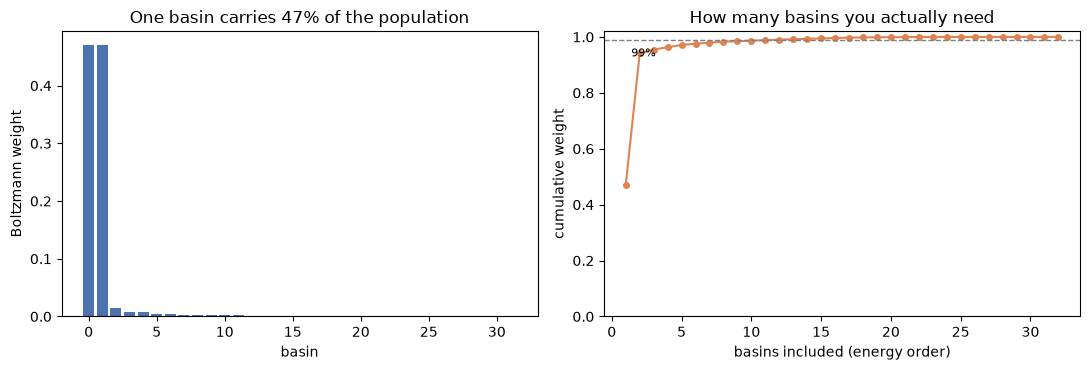

basins needed for 99% of the population: 12 of 32


In [18]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

ax[0].bar(range(len(w)), w, color="#4c72b0")
ax[0].set_xlabel("basin"); ax[0].set_ylabel("Boltzmann weight")
ax[0].set_title("One basin carries %.0f%% of the population" % (100 * w[0]))

ax[1].plot(range(1, len(w) + 1), np.cumsum(w), "o-", ms=4, color="#dd8452")
ax[1].axhline(0.99, ls="--", lw=1, color="grey")
ax[1].annotate("99%", (1, 0.99), textcoords="offset points", xytext=(4, -12), fontsize=8)
ax[1].set_xlabel("basins included (energy order)"); ax[1].set_ylabel("cumulative weight")
ax[1].set_ylim(0, 1.02); ax[1].set_title("How many basins you actually need")
plt.tight_layout(); plt.show()

n99 = int(np.searchsorted(np.cumsum(w), 0.99) + 1)
print("basins needed for 99%% of the population: %d of %d" % (n99, len(w)))

### The uncomfortable reading — and how it changed

**No single basin dominates: the lowest holds 47% of the population.** Four basins get you
to 96.3%, and it takes **twelve** to reach 99%. Thirty-two were found, tightened and
Hessian-screened; the last twenty contribute under 1% between them.

Note that "7 basins within 5 kT" and "12 basins to reach 99% of the weight" are different
questions with different answers — an energy window is not a weight threshold, and it is
easy to quote one while meaning the other.

> **This section used to say one basin held 92%, and that was an artefact.** Those numbers
> came from a run with `refine="opt"`, which returned 23 basins instead of 32 (section
> 2.4). The basins it failed to find were low-lying ones, so the survivors' weights were
> inflated and the distribution looked far more concentrated than it is. **A missing basin
> does not announce itself as missing — it shows up as the remaining basins looking more
> important.** That is the strongest argument in this notebook for not letting the search
> program decide what counts as a distinct structure.
>
> Expect your own run to differ too: iMTD-GC is stochastic, and two runs of these exact
> settings gave 37 and 32 basins. See `docs/branchA_workflow.md` section 8b.

It is tempting to conclude the search was wasted effort. It was not, and the reason is
worth being precise about:

- **You cannot know which basin is lowest until you have found them all.** The 47% basin
  is only identifiable as such after the search. Skipping the search does not give you the
  cheap answer, it gives you *an unknown answer*.
- **The conformational correction is the sum over all of them.** Measured for CREST-only
  ensembles in this project: mean +0.1209, max +0.5824 kcal/mol. That correction comes
  from precisely the low-weight tail.
- **The weights are on the current potential.** A different level of theory reorders
  near-degenerate conformers routinely. Basins 6 and 7 here differ by 0.21 kcal/mol; lower
  in the list the gaps are far smaller, and any reference recalculation may swap them.

What the distribution *does* tell you is where to spend the next, expensive step. If
you are going to run correlated wavefunction calculations on these geometries, the
cumulative-weight curve is how you decide how far down the list to go — and that
choice becomes a documented approximation rather than an accident.

In [19]:
kT = pop["kT_kcal"]
print("free-energy effect of truncating the basin list:")
print("%-10s %12s %14s" % ("keep top", "Σw", "ΔG error / kcal"))
cw = np.cumsum(w)
for k in (1, 2, 4, 8, 16, len(w)):
    err = -kT * np.log(cw[k - 1])
    print("%-10d %12.6f %14.4f" % (k, cw[k - 1], err))

free-energy effect of truncating the basin list:
keep top             Σw ΔG error / kcal
1              0.470472         0.4467
2              0.940944         0.0361
4              0.963056         0.0223
8              0.982579         0.0104
16             0.995974         0.0024
32             1.000000         0.0000


Keeping only the lowest basin costs **0.05 kcal/mol** here. That is small — for *this*
molecule, on *this* potential, at *this* temperature. The number is small because we
computed it, not because it was safe to assume.

# 7. The boundary: where these settings must not go

This is the part to remember after the syntax is forgotten.

Everything in section 2 exists to make the search **cross barriers**:

- a **bias potential** pushes the system out of the basin it is in;
- **SHAKE on all bonds** freezes bond stretches so a large timestep is stable;
- **deuterium masses** slow the fastest remaining motions so the step can be larger
  still.

Every one of those buys sampling by **destroying the physical thermal fluctuations**.
Branch A does not care, because *its product is a geometry.*

Now consider quasi-harmonic analysis, which extracts entropy from the covariance of
atomic fluctuations in an equilibrium trajectory. Apply the same settings and:

| setting | what it does to QHA |
|---|---|
| bias potential | flattens the fluctuations the method measures → **entropy comes out systematically high** |
| SHAKE on all bonds | removes bond-stretch degrees of freedom → the $3N-6$ non-zero eigenvalues **cannot all be filled** |
| H mass = 2 amu | drops C–H stretches from ~3000 to ~2200 cm⁻¹ → **every vibrational term is wrong** |

> A CREST trajectory is a **metadynamical** trajectory full of non-physical bias. It
> cannot be used to compute real vibrational frequencies or entropies.

The correct handover is **the basin geometries, not the trajectory**. Quasi-harmonic
analysis restarts from those with `dt = 1 fs`, `constraints = none`, real hydrogen
mass, and no bias — and uses not one frame of the CREST run.

The two stages share a molecule and a directory. They do not share a trajectory, and
they must not share a `.mdp`.

In [20]:
mdp = ROOT / "configs" / "mdp" / "s0_qha_production.mdp"
if mdp.exists():
    head = [l for l in mdp.read_text(encoding="utf-8").splitlines()][:26]
    print("\n".join(head))

; =====================================================================================
; stage 0 - Branch B - Quasi-Harmonic Analysis production trajectory
;
; IDENTITY: this is a PROTOCOL SPECIFICATION, not a job that is run.
;   Stage 0's potential is MACE-OFF23-SC. Production is driven by ASE
;   (scripts/production/s0_B_qha_trajectory.py). This file exists so every parameter is
;   written down once in a form that can be compared line-by-line with the
;   reference literature, and so GROMACS can read the SAME settings when it is
;   used as the independent cross-check of our S_QH / S_Schlitter (plan_B section 2).
;
; REFERENCE: Rinaldo & Field, Biophys. J. 2003, 85, 3485-3501.
;            Andricioaei & Karplus, J. Chem. Phys. 2001, 115, 6289 (the omega formula).
;
; *** THE THREE LINES THAT MATTER MOST ARE PROHIBITIONS, NOT SETTINGS ***
;
; A CREST metadynamics trajectory CANNOT be used here (S0-B-3, user ruling
; 2026-09-03). Three independent reasons, each fatal on its own:
;
;

# 8. The acceptance criteria

The pipeline checks itself against criteria written so that each one *can* fail, and
writes the verdicts into the product.

In [21]:
for ch in rec["criteria"]:
    tag = "N/A " if ch.get("not_applicable") else ("PASS" if ch["passed"] else "FAIL")
    print("%2s  %-62s %s" % (ch["number"], ch["criterion"][:62], tag))
print()
print("all passed:", rec["all_criteria_passed"])
print()
for ch in rec["criteria"]:
    if ch.get("not_applicable") or not ch["passed"]:
        print("#%s: %s" % (ch["number"], ch["detail"][:300]))

 1  workhorse identity                                             PASS
11  dynamics package written as one                                PASS
 2  cost claim is unambiguous                                      PASS
 4  zero imaginary, 6 rigid modes removed, separation > 1e8        PASS
 6  reference geometry pooled and located                          N/A 
 7  CREST, pooled and basin counts are three separate numbers that PASS
 9  sigma is a group order and is stable up to the working toleran PASS
10  published dynamics protocol, or a declared fallback            PASS
12  no merge crossed the energy threshold; criterion recorded      PASS

all passed: True

#6: NOT APPLICABLE: No deposited geometry exists for a SMILES-specified molecule, so step 3 pooled nothing and every structure below descends from CREST. The systematic error plan_A section 1.2 records for a CREST-only ensemble (mean +0.1209, max +0.5824 kcal/mol) is therefore UNBOUNDED here.


Criterion 6 is the one to look at. It did not pass — it is **not applicable**, and it
says why. A criterion that quietly passes when its subject is absent is worse than not
having the criterion at all, because it converts a gap in the evidence into an
apparent clean bill of health.

# 9. Exercises

**1 — Repeat the sweep on a molecule of your own.** The plateau in section 4.2 was
measured on two molecules; two is not many. Run
`scripts/calibration/s0_A_dedup_threshold_scan.py` on something floppier — a sugar, a
peptide fragment — and check whether the plateau is still 0.05–0.25 Å. If it moves, the
threshold is molecule-dependent, which is a far more interesting result than a
confirmation.

```python
rec2, basins2, mol2 = crest_census.census_from_frames(
    smiles, frames, calc, threshold_A=0.25, hessian_mode="analytic",
    ethr_kcal=None, bthr_rel=None)      # None restores the old RMSD-only rule
```

**2 — Does `refine="opt"` lose basins?** The quality layer re-optimises the ensemble
*before* CREST's own duplicate filter runs, so it can merge structures you would have
kept. Measured under the old `gfnff` workhorse on this same molecule: `opt` gave
**2926 s → 11 basins**, `sp` gave **496 s → 28 basins**. Under `gfn2` the effect is
**unmeasured** — the geometries are much better, so the merging should be weaker, but
"should be" is not a number. Run both and fill in the table. This is a real open item
in the project, not a made-up exercise.

**3 — Reproducibility.** CREST's metadynamics is stochastic. Run the same molecule
three times and report two columns: conformers CREST reports, and basins by our
criteria. On acetone the first column came out 1/2/3/2/5 across five repeats while the
second was 1/1/1/1/1 every time. Which column would you put in a paper?

**4 — Where the flexibility lives.** For each basin, compute the torsion angles of the
two C–O bonds and the backbone, and plot them coloured by Boltzmann weight. Do the
high-weight basins cluster? Is the 92% basin isolated or does it have near-degenerate
neighbours?

**5 — The one that matters most.** Take the 4 basins covering 99% of the population,
compute their $G - E_{el}$ terms (already in the record), and work out how much the
conformational correction changes if you use 4 basins instead of 22. Then decide, with
that number in hand, how many basins you would send to a correlated-wavefunction
calculation at ~44 s per gradient.

---

## What to take away

1. **A search program's conformer count is not a basin count.** 24 → 23 here; on
   acetone, 2 → 1 with the two "conformers" identical to the last digit after
   tightening. Always re-converge on your own surface with your own criteria.
2. **A production threshold must sit on a plateau, and somebody has to check.** This
   repository ran for weeks on a 0.30 Å threshold that had no source and whose config
   comment claimed a sweep nobody had run — while it was merging distinct minima up to
   2.2 kcal/mol apart.
3. **Use the published protocol, and use all of it.** SHAKE-all-bonds + 5 fs + 2 amu
   is one package; taking two of three aborted 29 metadynamics runs.
4. **The workhorse drives, the foundation model refines.** 107 966 gradient calls is
   not a budget you spend on a large model.
5. **Every parameter that changes the result is compared before a directory is
   reused** — including the timestep, which was missing until it was measured to
   matter.
6. **σ is per basin, comes from geometry, and is worth 0.411 kcal/mol per factor of
   two.** Demonstrated: ethylene glycol has nine basins with σ ∈ {1, 2} and an
   automorphism count of 8 for every one of them. Using the automorphism count costs
   **+1.041 kcal/mol** on the ensemble — the whole error budget, from one substitution.
7. **Boltzmann weights tell you what your search bought.** One basin at 92%, nine
   for 99% — and you only know which one *afterwards*.
8. **Sampling settings do not transfer to analysis settings.** The trajectory that
   found your conformers is not a trajectory you can take thermodynamics from.